In [24]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import scipy.stats as stats
import argparse
import warnings
warnings.filterwarnings("ignore")
import csv
import timeit
import time
import multiprocessing
from functools import partial
from scipy import stats
import numpy as np
# import milkviz as mv

In [4]:
group = pd.read_csv('/data1/DYY/bambu/288_group.csv',sep='\t')
data = pd.read_csv('/data1/DYY/bambu/288_count_matrix_deseq2/all_norm.counts.fn',sep='\t')

In [5]:
group['tissue'] = group['Sample ID'].str[:3]

In [8]:
tissue = group.tissue.drop_duplicates().tolist()

In [36]:
convert = pd.read_csv('/data1/DYY/bambu/CPM_transcript.txt',sep='\t')[['TXNAME','GENEID']]

## iso_ratio

In [51]:
test = pd.read_csv('/data1/DYY/bambu/counts_gene.txt',sep='\t',index_col=0)

In [58]:
test = test.rename(columns={'A2022617.01':'A2022617NT','A2022617.03':'A2022617NC'})

In [60]:
test_trans = pd.read_csv('/data1/DYY/bambu/counts_transcript.txt',sep='\t',index_col=0).rename(columns={'A2022617.01':'A2022617NT','A2022617.03':'A2022617NC'})

In [83]:
test_trans = test_trans.loc[test_trans.GENEID.str.contains('ENSG')]

In [76]:
test = test.loc[test.index.str.contains('ENSG')]

In [85]:
proportions = test_trans.copy()
samples = test.columns  # 所有样本列名

for sample in samples:
    # 获取对应基因的表达值
    gene_expression = test.loc[test_trans['GENEID'], sample].values

    # 创建一个布尔掩码，用于标记 gene_expression 中的非零项
    non_zero_mask = gene_expression != 0

    # 默认赋值为 0
    proportions[sample] = 0

    # 仅对非零基因表达项计算比例
    proportions.loc[non_zero_mask, sample] = (
        test_trans.loc[non_zero_mask, sample] / gene_expression[non_zero_mask]
    )


In [89]:
df = proportions.reset_index().set_index(['TXNAME','GENEID'])

In [99]:
df.loc[:,df.columns.isin(group.name)].to_csv('/data1/DYY/bambu/288isoform_ratio.csv',sep='\t')

In [146]:
for k,v in proportions.drop('GENEID',axis=1).T.reset_index().rename(columns={'index':'name'}).merge(group[['name','tissue']]).groupby('tissue'):
    v = v.loc[v.name.isin(group.name)]
    v.set_index('name').drop(['tissue'],axis=1).T.to_csv(f'/data1/DYY/bambu/288_mstrg_tpm/{k}.csv',sep='\t')


In [148]:
ir_test = pd.read_csv('/data1/DYY/bambu/288_mstrg_tpm/END.csv',sep='\t',index_col=0)

In [178]:
transcript_list = test_trans.index.tolist()

In [156]:
def ttest_by_group(transcript):
    # df = data.loc[data.Tissue==tissue]
    # dat = []
    data1 = df.loc[df.Type == 'Tumor'].sort_values('Sample ID')[[transcript]].astype(float)
    data2 = df.loc[df.Type == 'Normal'].sort_values('Sample ID')[[transcript]].astype(float)
    if (data1.notnull().sum().tolist()[0] >= 3) & (data2.notnull().sum().tolist()[0] >= 3) & (data1.sum().tolist()[0]>0) & (data2.sum().tolist()[0]>0):
    # df = df.drop(['Tissue','Type'], axis=1)
        ttest = stats.ttest_rel(data1,data2,nan_policy='omit')
        p = ttest[1][0]
        return p
    else :
        return np.nan
def process_list(lst, num_processes):
    # Use a multiprocessing pool to process the list in parallel
    with multiprocessing.Pool(processes=num_processes) as pool:
        result_list = pool.map(ttest_by_group, lst)
        return result_list

In [180]:
ir_path = '/data1/DYY/bambu/288_mstrg_tpm/'
# group = pd.read_csv('/data1/DYY/data/group.csv', sep='\t')
# corrected_df = pd.read_csv('/data1/DYY/data/1129isoform_ratio/all_trans_p_adj.csv',sep='\t',index_col=0)
files = [x for x in os.listdir(ir_path) if x[-3:]=='csv']
# ratio_df = pd.read_csv('/data1/DYY/bambu/288_mstrg_tpm/BLA.csv',sep='\t',index_col=0).drop(['Sample ID','Type'])
# transcript_list = corrected_df.index.to_list()
ttest_df = pd.DataFrame({'transcript':transcript_list})
for f in files:
    tis = f[:3]
    ratio_df = pd.read_csv(ir_path +f,sep='\t',index_col=0)#.head(1000)#.drop(['Sample ID','Type']) 
    df = ratio_df.T.reset_index().rename(columns={'index':'name'}).merge(group).set_index('name')#.fillna(0)
    new_line = process_list(transcript_list,40)
    new_df = pd.DataFrame({'transcript':transcript_list,tis:new_line})
    ttest_df = pd.merge(ttest_df,new_df,on='transcript')
    print(f'{tis} completed at ')
    print(time.strftime('%H:%M:%S',time.localtime(time.time())))
    # break
ttest_df.to_csv('/data1/DYY/bambu/288_mstrg_tpm/all_trans_p.csv',sep='\t',index=False)

BLA completed at 
22:52:28
REC completed at 
23:18:09
COL completed at 
00:48:15
END completed at 
01:11:14
LUN completed at 
03:01:26
BRE completed at 
04:50:49
KID completed at 
06:46:53
STO completed at 
07:20:52
LIV completed at 
09:04:01
CER completed at 
10:25:15


In [ ]:
ir_path = '/data1/DYY/bambu/288_'
# group = pd.read_csv('/data1/DYY/data/group.csv', sep='\t')
# corrected_df = pd.read_csv('/data1/DYY/data/1129isoform_ratio/all_trans_p_adj.csv',sep='\t',index_col=0)
files = [x for x in os.listdir(ir_path) if x[-3:]=='csv']
# ratio_df = pd.read_csv('/data1/DYY/bambu/288_mstrg_tpm/BLA.csv',sep='\t',index_col=0).drop(['Sample ID','Type'])
# transcript_list = corrected_df.index.to_list()
ttest_df = pd.DataFrame({'transcript':transcript_list})
for f in files:
    tis = f[:3]
    ratio_df = pd.read_csv(ir_path +f,sep='\t',index_col=0)#.head(1000)#.drop(['Sample ID','Type']) 
    df = ratio_df.T.reset_index().rename(columns={'index':'name'}).merge(group).set_index('name')#.fillna(0)
    new_line = process_list(transcript_list,40)
    new_df = pd.DataFrame({'transcript':transcript_list,tis:new_line})
    ttest_df = pd.merge(ttest_df,new_df,on='transcript')
    print(f'{tis} completed at ')
    print(time.strftime('%H:%M:%S',time.localtime(time.time())))
    # break
ttest_df.to_csv('/data1/DYY/bambu/288_mstrg_tpm/all_trans_p.csv',sep='\t',index=False)

In [184]:
from statsmodels.stats.multitest import fdrcorrection

In [186]:
correction_df = ttest_df.set_index('transcript')
corrected_df = pd.DataFrame(index=correction_df.index)
for t in correction_df.columns:
    unempty = correction_df[[t]].dropna()
    fdr = fdrcorrection(unempty[t])[1]
    unempty.loc[:,t] = fdr
    corrected_df = pd.merge(corrected_df,unempty,left_index=True,right_index=True,how='outer')

In [190]:
corrected_df.to_csv('/data1/DYY/bambu/288_mstrg_tpm/all_trans_padj.csv',sep='\t')

In [26]:
corrected_df = pd.read_csv('/data1/DYY/bambu/288_mstrg_tpm/all_trans_padj.csv',sep='\t',index_col=0)

In [28]:
sig_trans = corrected_df[corrected_df<0.05]
sig_trans = sig_trans.loc[sig_trans.count(axis=1)>0]

In [44]:
sig_trans['BLA'].dropna().reset_index().rename(columns={'transcript':'TXNAME'}).merge(convert).drop_duplicates('GENEID')

,TXNAME,BLA,GENEID
0,BambuTx10398,0.018250,ENSG00000067208.16
1,BambuTx11340,0.037408,ENSG00000084733.11
2,BambuTx1179,0.043350,ENSG00000134769.23
3,BambuTx1307,0.039344,ENSG00000169021.6
4,BambuTx1482,0.002555,ENSG00000168734.14
...,...,...,...
417,ENST00000698979.1,0.043750,ENSG00000106628.13
418,ENST00000700619.1,0.035761,ENSG00000105223.21
420,ENST00000702546.1,0.011897,ENSG00000291109.1
421,ENST00000702913.1,0.040906,ENSG00000291152.1


In [40]:
sig_trans.reset_index().rename(columns={'transcript':'TXNAME'}).merge(convert).drop_duplicates('GENEID')

,TXNAME,BLA,REC,COL,END,LUN,BRE,KID,STO,LIV,CER,GENEID
0,BambuTx1037,NaN,NaN,NaN,NaN,NaN,NaN,0.045075,NaN,0.022672,NaN,ENSG00000108861.9
1,BambuTx10398,0.018250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENSG00000067208.16
2,BambuTx10428,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.013502,NaN,ENSG00000143303.12
3,BambuTx10494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.020403,NaN,ENSG00000119820.11
4,BambuTx1054,NaN,NaN,NaN,NaN,NaN,NaN,0.005482,NaN,NaN,NaN,ENSG00000005243.10
...,...,...,...,...,...,...,...,...,...,...,...,...
1508,ENST00000700726.1,NaN,NaN,NaN,NaN,0.01236,NaN,NaN,NaN,NaN,NaN,ENSG00000161649.14
1509,ENST00000701959.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001405,NaN,ENSG00000291128.1
1510,ENST00000702546.1,0.011897,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENSG00000291109.1
1511,ENST00000702913.1,0.040906,NaN,NaN,NaN,NaN,0.008162,NaN,NaN,NaN,NaN,ENSG00000291152.1


In [138]:
df_long = sig_trans.reset_index().melt(id_vars=["transcript"], var_name="tissue", value_name="ratio_padj").dropna().sort_values(by="transcript")

In [162]:
len(df_long)

1697

In [177]:
df_long.rename(columns={'transcript':'TXNAME'}).merge(convert).merge(gene_name).set_index('GENEID').iloc[].sort_values().to_csv('/data1/DYY/bambu/s12.csv',sep='\t',index=False)#.merge(gene_name.rename(columns={'ensg':'GENEID'})[['GENEID','gene_name']].drop_duplicates())

,TXNAME,tissue,ratio_padj,GENEID,gene_name
0,BambuTx1037,KID,0.045075,ENSG00000108861.9,DUSP3
1,BambuTx1037,LIV,0.022672,ENSG00000108861.9,DUSP3
2,ENST00000226004.8,LIV,0.031718,ENSG00000108861.9,DUSP3
3,BambuTx10398,BLA,0.018250,ENSG00000067208.16,EVI5
4,BambuTx10428,LIV,0.013502,ENSG00000143303.12,METTL25B
...,...,...,...,...,...
1692,ENST00000701959.1,LIV,0.001405,ENSG00000291128.1,APOC1P1
1693,ENST00000702546.1,BLA,0.011897,ENSG00000291109.1,CES1P1
1694,ENST00000702913.1,BLA,0.040906,ENSG00000291152.1,SBDSP1
1695,ENST00000702913.1,BRE,0.008162,ENSG00000291152.1,SBDSP1


In [175]:
gene_name = pd.read_csv('/data1/DYY/bambu/geneid_gene_name.csv',sep='\t')

In [142]:
tpm_data = pd.read_csv('/data1/DYY/bambu/288_count_matrix_deseq2/all_trans_norm.counts.fn',sep='\t')

In [146]:
tpm_data = tpm_data.T.reset_index().rename(columns={'index':'name'}).merge(group)

In [208]:
tpm_tissue={}
for t in tissue:
    tpm_tissue[t] = pd.DataFrame((tpm_data.loc[(tpm_data.tissue==t) & (tpm_data.Type=='Tumor')].mean() )- (tpm_data.loc[(tpm_data.tissue==t) & (tpm_data.Type=='Normal')].mean() ))

In [187]:
df_long = df_long.set_index('transcript')

In [212]:
for t in tissue:
    try:
        df_long.loc[(df_long.tissue==t),'tpm_diff'] = tpm_tissue[t][0]
    except:
        continue

In [235]:
df_long = df_long.reset_index().rename(columns={'transcript':'TXNAME'}).merge(convert)#.merge(gene_name).to_csv('/data1/DYY/bambu/s12.csv',sep='\t')

In [245]:
ts_df_long = df_long.copy()
for t in tissue:
    ts_trans = pd.read_csv('/data1/DYY/bambu/288_tumor_specific_trans/'+t,header=None)
    try:
        ts_df_long.loc[(ts_df_long.TXNAME.isin(ts_trans[0])),'ts'] = 1
    except:
        continue

In [251]:
ts_df_long.loc[ts_df_long.ts==1].merge(gene_name).gene_name.tolist()

['METTL25B',
 'YIPF4',
 'RAB10',
 'CDK4',
 'GATM',
 'UTP4',
 'MAD1L1',
 'DHRS2',
 'BGN',
 'PPP1CB',
 'PPP1CB',
 'DYNC1I1',
 'IL13RA2',
 'H2BC17',
 'SLC39A5',
 'KCNT2',
 'TIA1',
 'FGF7',
 'TMEM132A',
 'TMEM132A',
 'MAPK8IP2',
 'MISP',
 'CYP4F2',
 'IBSP',
 'DNASE1',
 'MCHR1',
 'PPP1R1B',
 'TCN1',
 'ESPL1',
 'MMP13',
 'EPYC',
 'GRIN2D',
 'PITX1',
 'MYRF',
 'ANLN',
 'TICRR',
 'EPN3',
 'NUF2',
 'RIPPLY1',
 'OTX1',
 'XAGE2',
 'IGF2BP1',
 'LRFN5',
 'AGAP1',
 'GAP43',
 'UGT2B7',
 'KLK6',
 'SH2D3C',
 'AQP6',
 'SOX11',
 'CDC25C',
 'CYP2B6',
 'FLNC',
 'NOL4L',
 'IL20RB',
 'B4GALNT4',
 'CDCA2',
 'STAC3',
 'H2AC14',
 'H2AC14',
 'OIT3',
 'IL21R',
 'CRISP2',
 'B4GALNT1',
 'B4GALNT1',
 'DUSP9',
 'DUSP9',
 'DUSP9',
 'KCNQ4',
 'KCNQ4',
 'MAPT',
 'AK2',
 'TPM1',
 'IQGAP3',
 'IQGAP3',
 'ZC3H11A',
 'ASPM',
 'C1orf43',
 'MAP3K7',
 'FLNA',
 'HS6ST2',
 'DEPDC1',
 'RAD54L',
 'NTMT1',
 'KCNK17',
 'AUNIP',
 'AUNIP',
 'TNXB',
 'TNXB',
 'GABRD',
 'TNFRSF4',
 'CD99',
 'VLDLR',
 'FAXC',
 'TES',
 'KRT80',
 'LRRC20',


In [324]:
# padj = pd.read_csv('/data1/DYY/data/all_trans_p_adj.csv', sep='\t',index_col=0)
# group = pd.read_csv('/data1/DYY/data/288_group.csv',sep='\t')
# # convert = pd.read_csv('/data1/DYY/data/mstrg_ensg_transcript.csv', sep='\t')
# # gene_name = pd.read_csv('/data1/DYY/data/ensg_gene_name.csv', sep='\t').drop_duplicates()
# padj_dict = {}
# for column in padj.columns:
#     padj_dict[column] = padj[padj[column]<0.05][[column]]
tpm_padj = {}
for column in padj.columns:
    tpm_padj[column] = corrected_df[corrected_df[column]<0.05][[column]]

In [ ]:
# # %%time
# ttest_df = pd.DataFrame({'transcript':transcript_list})
# for f in files:
#     tis = f[:3]
#     ratio_df = pd.read_csv('/data1/HOMO_PANGENOME/DYY/data/288_mstrg_tpm/'+f,sep='\t',index_col=0).drop(['Sample ID','Type'])
#     df = ratio_df.T.reset_index().rename(columns={'index':'name'}).merge(group).set_index('name').fillna(0)
#     # df = ratio_df.T
#     # transcript_list = df.drop(['Sample ID','Type'], axis=1).columns.to_list()
#     # break
#     new_line = process_list(transcript_list,40)
#     new_df = pd.DataFrame({'transcript':transcript_list,tis:new_line})
#     ttest_df = pd.merge(ttest_df,new_df,on='transcript')
#     # print(f'{tis} completed at ')
#     # print(time.strftime('%H:%M:%S',time.localtime(time.time())))
# ttest_df.to_csv('/data1/HOMO_PANGENOME/DYY//288_mstrg_tpm/all_trans_p.csv',sep='\t',index=False)

In [32]:
padj = pd.read_csv('/data1/DYY/bambu/288_mstrg_tpm/all_trans_padj.csv', sep='\t',index_col=0)
# padj = pd.read_csv('/data1/DYY/data/1129isoform_ratio/all_trans_p_adj.csv', sep='\t',index_col=0)
padj_dict = {}
for column in padj.columns:
    padj_dict[column] = padj[padj[column]<0.05][[column]]

In [899]:
desgene = pd.read_csv('/data1/DYY/bambu/desgene_all_tissue.csv',sep='\t')

In [952]:
pd.read_csv(f'/data1/DYY/bambu/288_count_matrix_deseq2/{column}_result.csv',sep='\t').set_index('row').loc[gene]

baseMean          147.279869
log2FoldChange     -2.362844
lfcSE               0.487136
stat               -4.850484
pvalue              0.000001
padj                0.000032
Name: ENSG00000196923.14, dtype: float64

In [44]:
desgene_dict = {}
for column in padj.columns:
    desgene_data = pd.read_csv(f'/data1/DYY/bambu/288_count_matrix_deseq2/{column}_result.csv',sep='\t')
    # desgene = desgene_data[desgene_data['sums']>0][['ensg']]
     
    desgene_dict[column] = desgene_data.loc[~((desgene_data.padj<0.05) & ((desgene_data.log2FoldChange<-1) | (desgene_data.log2FoldChange>1)))]

In [19]:
gene_name = pd.read_csv('/data1/DYY/data/ensg_gene_name.csv', sep='\t').drop_duplicates()
convert = pd.read_csv('/data1/DYY/data/mstrg_ensg_transcript.csv', sep='\t')
gene_name = gene_name.rename(columns={'1':'ensg','7':'gene_name'}).merge(convert)

In [23]:
ir_path = '/data1/DYY/data/288_mstrg_tpm/'
# group = pd.read_csv('/data1/DYY/data/group.csv', sep='\t')
corrected_df = pd.read_csv('/data1/DYY/data/1129isoform_ratio/all_trans_p_adj.csv',sep='\t',index_col=0)
files = [x for x in os.listdir(ir_path) if x[-3:]=='csv']
ratio_df = pd.read_csv('/data1/DYY/data/288_mstrg_tpm/BLA.csv',sep='\t',index_col=0).drop(['Sample ID','Type'])
transcript_list = corrected_df.index.to_list()
ttest_df = pd.DataFrame({'transcript':transcript_list})
for f in files:
    tis = f[:3]
    ratio_df = pd.read_csv('/data1/DYY/data/288_mstrg_tpm/'+f,sep='\t',index_col=0).drop(['Sample ID','Type'])
    df = ratio_df.T.reset_index().rename(columns={'index':'name'}).merge(group).set_index('name').fillna(0)
    new_line = process_list(transcript_list,40)
    new_df = pd.DataFrame({'transcript':transcript_list,tis:new_line})
    ttest_df = pd.merge(ttest_df,new_df,on='transcript')
    print(f'{tis} completed at ')
    print(time.strftime('%H:%M:%S',time.localtime(time.time())))
ttest_df.to_csv('/data1/DYY/bambu/288_mstrg_tpm/all_trans_p.csv',sep='\t',index=False)

BLA completed at 
16:49:17
REC completed at 
16:54:51
COL completed at 
17:07:42
END completed at 
17:13:19
LUN completed at 
17:25:23
BRE completed at 
17:38:17
KID completed at 
17:51:19
STO completed at 
18:00:14
LIV completed at 
18:13:48
CER completed at 
18:21:03


In [23]:
ttest_df = pd.read_csv('/data1/DYY/data/288_mstrg_tpm/all_trans_p.csv',sep='\t')

In [29]:
corrected_df.to_csv('/data1/DYY/data/288_mstrg_tpm/all_trans_padj.csv',sep='\t')

In [6]:
corrected_df = pd.read_csv('/data1/DYY/data/288_mstrg_tpm/all_trans_padj.csv',sep='\t')

In [255]:
corrected_df = corrected_df[corrected_df<0.05]

In [259]:
corrected_df = corrected_df.loc[corrected_df.count(axis=1)>0]

In [266]:
bambu_convert = pd.read_csv('/data1/DYY/bambu/CPM_transcript.txt',sep='\t')[['TXNAME','GENEID']]

In [320]:
ttest_df.loc[ttest_df.transcript.isin(['BambuTx31915',
 'ENST00000381775.5',
 'ENST00000405957.6',
 'ENST00000406638.6',
 'ENST00000485341.5',
 'ENST00000612798.4'])]

,transcript,BLA,REC,COL,END,LUN,BRE,KID,STO,LIV,CER
15773,BambuTx31915,0.848231,NaN,NaN,NaN,NaN,NaN,0.338265,NaN,0.270182,NaN
47115,ENST00000381775.5,0.207116,NaN,NaN,0.765820,0.678096,0.325087,0.471729,NaN,0.240470,0.034177
55579,ENST00000405957.6,0.207116,0.035136,0.039333,0.213133,0.272371,0.143582,0.549676,0.051297,0.240470,0.718563
55781,ENST00000406638.6,0.293268,0.101341,0.001693,0.035872,0.702645,0.086104,0.440212,0.047319,0.240470,0.020351
108242,ENST00000485341.5,0.425298,NaN,NaN,0.661057,NaN,0.509200,0.471729,NaN,0.300285,0.150483
200981,ENST00000612798.4,0.207116,0.664906,NaN,0.874150,0.678096,0.325087,0.471729,NaN,0.240470,0.062099


In [314]:
corrected_df.loc[corrected_df.index.isin(['BambuTx31915',
 'ENST00000381775.5',
 'ENST00000405957.6',
 'ENST00000406638.6',
 'ENST00000485341.5',
 'ENST00000612798.4'])]

,BLA,REC,COL,END,LUN,BRE,KID,STO,LIV,CER
transcript,,,,,,,,,,


## 6F data

In [278]:
test = corrected_df.reset_index().rename(columns={'transcript':'TXNAME'}).merge(bambu_convert).groupby('GENEID').count()
len(test.loc[test.TXNAME>1])

267

In [515]:
convert

,TXNAME,GENEID
0,BambuTx1,ENSG00000228037.1
1,BambuTx2,BambuGene4000
2,BambuTx3,ENSG00000037637.11
3,BambuTx4,ENSG00000219481.11
4,BambuTx5,ENSG00000291072.1
...,...,...
296460,ENST00000706429.1,ENSG00000245248.9
296461,ENST00000706430.1,ENSG00000245248.9
296462,ENST00000706431.1,ENSG00000106829.21
296463,ENST00000706486.1,ENSG00000291301.1


In [523]:
len(corrected_df.loc[(~corrected_df.BLA.isnull()) & (corrected_df.index.str.startswith('B'))].reset_index().rename(columns={'transcript':'TXNAME'}).merge(convert).GENEID.drop_duplicates())

32

In [531]:
ir_diff = pd.read_csv('/data1/DYY/bambu/288_ir_ratio_t-n.csv',sep='\t',index_col=0)

In [549]:
convert_df = convert_df[['TXNAME','ensg','gene_name']]

In [597]:
ir_data = pd.read_csv('/data1/DYY/bambu/288_mstrg_tpm/BLA.csv',sep='\t',index_col=0).T.reset_index().rename(columns={'index':'name'}).merge(group).set_index('name')

In [703]:
plot_data = {}
for t in tissue:
    ir_sig_trans = corrected_df.loc[corrected_df[t].notnull()]
    plot_data[t] = ir_diff.loc[ir_sig_trans.index,ir_diff.columns.str.contains(t)].mean(axis=1).abs().sort_values().tail(2).reset_index().merge(convert_df.rename(columns={'TXNAME':'transcript'}))[['transcript',0,'gene_name']]

plot_n = pd.DataFrame(index=pd.concat(plot_data).transcript.tolist(),columns=['BLA','BRE','COL','KID','LIV','LUN'])
plot_t = pd.DataFrame(index=pd.concat(plot_data).transcript.tolist(),columns=['BLA','BRE','COL','KID','LIV','LUN'])

for t in plot_n.columns:
    ir_data = pd.read_csv(f'/data1/DYY/bambu/288_mstrg_tpm/{t}.csv',sep='\t',index_col=0).T.reset_index().rename(columns={'index':'name'}).merge(group).set_index('name')
    for trans in plot_t.index:
        plot_n.loc[trans,t] = ir_data.loc[(ir_data.Type=='Normal'),trans].mean()
        plot_t.loc[trans,t] = ir_data.loc[(ir_data.Type=='Tumor'),trans].mean()

plot_n.reset_index().rename(columns={'index':'TXNAME'}).merge(convert_df[['TXNAME','gene_name']]).set_index('gene_name').drop('TXNAME',axis=1).to_csv('/data1/DYY/bambu/6F_data_normal.csv',sep='\t')

plot_t.reset_index().rename(columns={'index':'TXNAME'}).merge(convert_df[['TXNAME','gene_name']]).set_index('gene_name').drop('TXNAME',axis=1).to_csv('/data1/DYY/bambu/6F_data_tumor.csv',sep='\t')

In [704]:
pd.read_csv('/data1/DYY/bambu/288_mstrg_tpm/all_trans_padj.csv',sep='\t',index_col=0).loc[plot_t.index,plot_t.columns].fillna(1).to_csv('/data1/DYY/bambu/6F_data_padj.csv',sep='\t')

# iso_ratio & tpm signifiacnt not desgene

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
convert_df = convert.rename(columns={'GENEID':'ensg'}).merge(gene_name.drop_duplicates('ensg'))

In [23]:
tpm_bambu = pd.read_csv('/data1/DYY/bambu/288_count_matrix_deseq2/all_trans_norm.counts.fn',sep='\t')
tpm_bambu = tpm_bambu.T.reset_index().rename(columns={'index':'name'}).merge(group).drop('Sample ID',axis=1)

In [24]:
gene_tpm = pd.read_csv('/data1/DYY/bambu/288_count_matrix_deseq2/all_norm.counts.fn',sep='\t')

In [25]:
gene_tpm = gene_tpm.T.reset_index().rename(columns={'index':'name'}).merge(group)

In [917]:
pd.read_csv('/data1/DYY/bambu/288_count_matrix_deseq2/BLA_result.csv',sep='\t').set_index('row').loc['ENSG00000135269.18']

baseMean          63.466289
log2FoldChange    -1.135340
lfcSE              0.343193
stat              -3.308162
pvalue             0.000939
padj               0.008068
Name: ENSG00000135269.18, dtype: float64

In [57]:
my_dict = {}
filtered_dict = {}
for column in padj.columns:
    # ir_df = padj_dict[column].reset_index().rename(columns={column:'ir_padj'})
    ir_df = corrected_df.loc[corrected_df[column]<0.05][[column]].reset_index()
    des_gene = desgene_dict[column]
    # merge_df = ir_df.merge(tpm_df).merge(gene_name)
    merge_df = ir_df.rename(columns={'transcript':'TXNAME'}).merge(convert)
    df = merge_df[merge_df.GENEID.isin(des_gene.row)]
    my_dict[column] = df
    df = df[df.duplicated('GENEID',keep=False)].sort_values('GENEID')
    ir_dat = pd.read_csv(f'/data1/DYY/bambu/288_mstrg_tpm/{column}.csv',sep='\t',index_col=0)
    ir_dat = ir_dat.T.reset_index().rename(columns={'index':'name'}).merge(group).drop('Sample ID',axis=1)
    # tpm_data = tpm_bambu.loc[tpm_bambu.tissue==column].drop(['tissue','name'],axis=1)
    # ir_dat = ir_dat.loc[:,ir_dat.columns.isin(df.TXNAME)]
    tpm_diff = pd.DataFrame({'Normal':(ir_dat.loc[ir_dat.Type=='Normal'].mean()),'Tumor':(ir_dat.loc[ir_dat.Type=='Tumor'].mean())})
    diff = tpm_diff.reset_index().rename(columns={'index':'TXNAME',0:'diff'}).merge(df)
    filtered_dict[column] = diff
    # break

In [59]:
from scipy.stats import ttest_ind

In [78]:
plot_dict={}
for column in padj.columns:
    plot_dict[column] = {}
    filtered_dict[column].sort_values(column).head(20)
    selected_gene = filtered_dict[column].sort_values(column).head(5).drop_duplicates('GENEID').GENEID.tolist()
    selected_trans = filtered_dict[column].loc[filtered_dict[column].GENEID.isin(selected_gene)].TXNAME.tolist()
    ir_data = pd.read_csv(f'/data1/DYY/bambu/288_mstrg_tpm/{column}.csv',sep='\t',index_col=0).T.reset_index().rename(columns={'index':'name'}).merge(group)
    for gene in selected_gene:
        plot_tpm = gene_tpm.loc[gene_tpm.tissue==column,[gene,'Sample ID','Type']]
        test_plot = ir_data.set_index(['Sample ID','Type']).loc[:,selected_trans].reset_index().merge(plot_tpm,on=['Sample ID','Type'])
        plot_dict[column][gene] = test_plot
        # if len(test_plot)>0:
        #     print(column,gene_name.loc[gene_name.ensg==gene][['gene_name','ensg']].drop_duplicates())
        # break
    # break

In [105]:
normal_primary = pd.read_csv('/data1/DYY/bambu/all_tissue_normal_primary.csv',sep='\t',index_col=0)

In [107]:
normal_primary = normal_primary.reset_index().rename(columns={'index':'TXNAME'}).merge(convert)

In [111]:
normal_primary.loc[normal_primary.GENEID=='ENSG00000128951.14']

,TXNAME,BLA,BRE,CER,COL,END,KID,LIV,LUN,REC,STO,GENEID
12463,ENST00000331200.8,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,ENSG00000128951.14
66731,ENST00000455976.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENSG00000128951.14
145733,ENST00000558367.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENSG00000128951.14
145827,ENST00000558472.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENSG00000128951.14
146144,ENST00000558813.5,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,ENSG00000128951.14
146298,ENST00000558978.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENSG00000128951.14
146707,ENST00000559416.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENSG00000128951.14
146822,ENST00000559540.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENSG00000128951.14
147110,ENST00000559852.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENSG00000128951.14
147186,ENST00000559935.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENSG00000128951.14


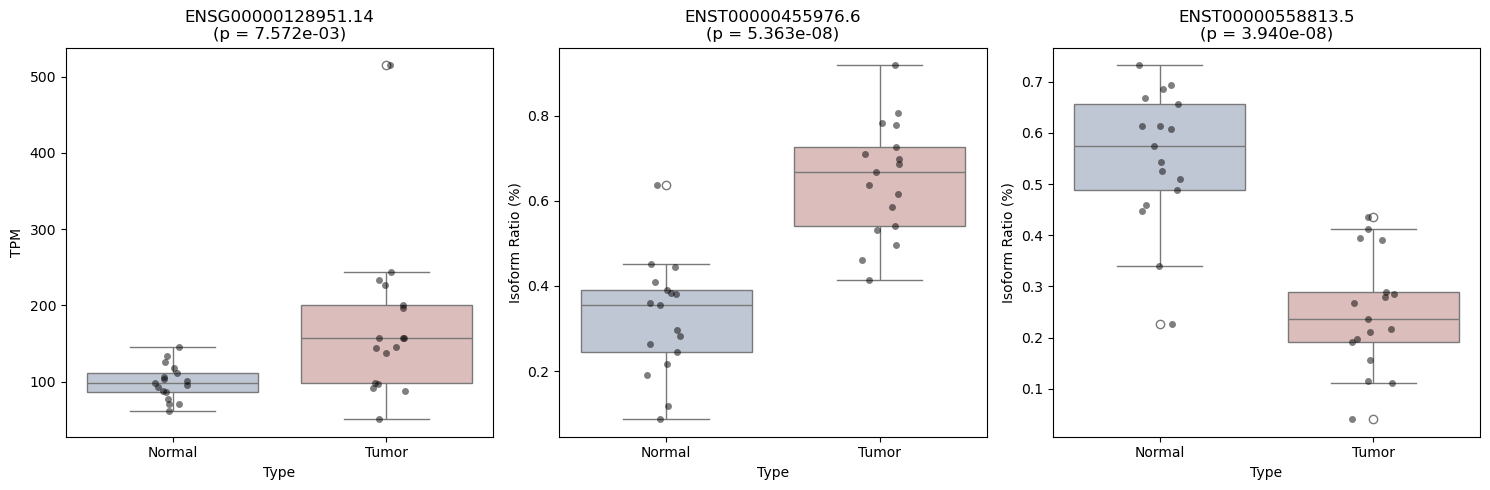

In [96]:
test_plot = plot_dict['LIV']['ENSG00000128951.14']
# 提取基因和转录本列
gene_column = [col for col in test_plot.columns if col.startswith("ENSG")][0]
transcript_columns = filtered_dict['LIV'].loc[filtered_dict['LIV'].GENEID=='ENSG00000128951.14'].TXNAME.tolist()

# 重整数据
data_melted = pd.melt(test_plot, id_vars=["Sample ID", "Type"], value_vars=[gene_column] + transcript_columns,
                      var_name="Feature", value_name="Value")

def calculate_pvalue(data, feature):
    normal_values = data[(data["Feature"] == feature) & (data["Type"] == "Normal")]["Value"]
    tumor_values = data[(data["Feature"] == feature) & (data["Type"] == "Tumor")]["Value"]
    stat, pval = ttest_ind(normal_values, tumor_values)
    return pval

# 重整数据
# data_melted = pd.melt(data, id_vars=["Sample ID", "Type"], value_vars=[gene_column] + transcript_columns,
#                       var_name="Feature", value_name="Value")

# 绘制基因表达水平图（左侧）
plt.figure(figsize=(15, 5))
plt.subplot(1, len(transcript_columns) + 1, 1)  # 左图
sns.boxplot(data=data_melted[data_melted["Feature"] == gene_column],
            x="Type", y="Value", palette="vlag")
sns.stripplot(data=data_melted[data_melted["Feature"] == gene_column],
              x="Type", y="Value", color='black', alpha=0.5, jitter=True)
pval = calculate_pvalue(data_melted, gene_column)
plt.title(f"{gene_column}\n(p = {pval:.3e})")
plt.ylabel("TPM")

# 绘制转录本分布（右侧每个转录本）
for i, transcript in enumerate(transcript_columns, start=2):
    plt.subplot(1, len(transcript_columns) + 1, i)
    sns.boxplot(data=data_melted[data_melted["Feature"] == transcript],
                x="Type", y="Value", palette="vlag")
    sns.stripplot(data=data_melted[data_melted["Feature"] == transcript],
                  x="Type", y="Value", color='black', alpha=0.5, jitter=True)
    pval = calculate_pvalue(data_melted, transcript)
    plt.title(f"{transcript}\n(p = {pval:.3e})")
    plt.ylabel("Isoform Ratio (%)")

plt.tight_layout()
# plt.show()
plt.savefig('/data1/DYY/bambu/plot/figure5/5d_tpm_DUT_in_liv.pdf',dpi=400,bbox_inches='tight')

In [796]:
gene_name.loc[gene_name.ensg=='ENSG00000135269.18']

,ensg,gene_name,mstrg,transcript
30680,ENSG00000135269.18,TES,MSTRG.95257,MSTRG.95257.1
30681,ENSG00000135269.18,TES,MSTRG.95257,MSTRG.95257.2
30682,ENSG00000135269.18,TES,MSTRG.95257,MSTRG.95257.3


In [443]:
selected_trans = pd.concat(my_dict)['TXNAME'].tolist()

In [467]:
selected_genes = corrected_df.loc[corrected_df.index.isin(selected_trans)].reset_index().rename(columns={'transcript':'TXNAME'}).merge(convert_df).groupby('ensg').count().sort_values('TXNAME').tail(10).index.tolist()

In [483]:
txname = convert.loc[convert.GENEID.isin(selected_genes)].TXNAME.tolist()

In [475]:
gene_name.loc[gene_name.ensg=='ENSG00000154723.13']

,ensg,gene_name,mstrg,transcript
68919,ENSG00000154723.13,ATP5PF,MSTRG.203263,MSTRG.203263.1
68920,ENSG00000154723.13,ATP5PF,MSTRG.203292,MSTRG.203292.1
68921,ENSG00000154723.13,ATP5PF,MSTRG.203292,MSTRG.203292.2
68922,ENSG00000154723.13,ATP5PF,MSTRG.203292,MSTRG.203292.3
68923,ENSG00000154723.13,ATP5PF,MSTRG.203292,MSTRG.203292.4


In [433]:
pd.concat(my_dict)#.drop('level_1',axis=1).rename(columns={'level_0':'tissue','ensg':'ensembl_id'}).set_index('tissue')

TXNAME       BLA  REC  COL  END  LUN  BRE  KID  STO  \
BLA 0         BambuTx10398  0.018250  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
    1         BambuTx11340  0.037408  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
    3          BambuTx1307  0.039344  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
    5          BambuTx1607  0.047823  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
    6         BambuTx17328  0.003032  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
...                    ...       ...  ...  ...  ...  ...  ...  ...  ...   
LIV 244  ENST00000649215.1       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
    245  ENST00000650070.2       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
    247  ENST00000675947.1       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
    248  ENST00000676829.1       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
    250  ENST00000689415.1       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

              LIV  CER  
BLA 0         NaN  NaN  
    1         NaN  NaN  
    3         NaN  NaN  
    5         NaN  NaN  
    6         NaN  NaN  
...           ...  ...  
LIV 244  0.001181  NaN  
    245  0.039902  NaN  
    247  0.037362  NaN  
    248  0.034855  NaN  
    250  0.039227  NaN  

[941 rows x 11 columns]

In [714]:
pd.concat(my_dict).reset_index().drop('level_1',axis=1)

,level_0,TXNAME,BLA,REC,COL,END,LUN,BRE,KID,STO,LIV,CER
0,BLA,BambuTx10398,0.018250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BLA,BambuTx11340,0.037408,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BLA,BambuTx1307,0.039344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BLA,BambuTx1607,0.047823,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BLA,BambuTx17328,0.003032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
936,LIV,ENST00000649215.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001181,NaN
937,LIV,ENST00000650070.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.039902,NaN
938,LIV,ENST00000675947.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.037362,NaN
939,LIV,ENST00000676829.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.034855,NaN


In [75]:
pd.concat(my_dict).reset_index().drop('level_1',axis=1).rename(columns={'level_0':'tissue','ensg':'ensembl_id'}).set_index('tissue').to_csv('/data1/DYY/data/1129isoform_ratio/ir_tpm_sig_not_desgene.csv',sep='\t')

### iso_ratio sig & desgene

In [7]:
padj = pd.read_csv('/data1/DYY/data/isoform_ratio/trans_ratio_ttest_p_fdr.csv', sep='\t',index_col=0).T
# padj = pd.read_csv('/data1/DYY/data/1129isoform_ratio/all_trans_p_adj.csv', sep='\t',index_col=0)
padj_dict = {}
for column in padj.columns:
    padj_dict[column] = padj[padj[column]<0.05][[column]]

In [192]:
pd.read_csv(f'/data1/DYY/bambu/288_mstrg_tpm/BLA.csv',sep='\t',index_col=0)

,A1803947PD1TN2,A1803947PD1TT2,A1803953PD1TN1,A1803953PD1TT2,A1804216PD1TN1,A1804216PD1TT3,A1804218PD1TN2,A1804218PD1TT3,A1900134PD1TN3,A1900134PD1TT3,...,A1901254PD1TN3,A1901254PD1TT3,A1901739PD1TN2,A1901739PD1TT3,A1901740PD1TN3,A1901740PD1TT2,A1901741PD1TN3,A1901742PD1TN3,A1901742PD1TT2,A1901744PD1TT1
BambuTx1,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
BambuTx3,0.000000,0.144059,0.055556,0.099819,0.052632,0.00000,0.133031,0.199191,0.076522,0.034457,...,0.000000,0.0,0.166334,0.013058,0.000000,0.206885,0.157142,0.043590,0.052758,0.035714
BambuTx4,0.429652,0.000000,0.000000,0.152533,0.000000,0.07364,0.090909,0.134797,0.000000,0.000000,...,0.000000,0.0,0.148528,0.000000,0.000000,0.000000,0.000000,0.011177,0.144171,1.000000
BambuTx5,0.233766,0.428571,0.500000,0.000000,0.500000,0.00000,0.263736,0.125000,0.085714,0.500000,...,0.000000,0.0,0.142857,0.409091,0.375000,0.000000,0.000000,0.250000,0.201681,0.000000
BambuTx6,0.067945,0.177959,0.068471,0.000000,0.057692,0.00000,0.117210,0.059292,0.087680,0.036572,...,0.098859,0.0,0.020451,0.030825,0.063267,0.187258,0.067680,0.053824,0.091428,0.066699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENST00000706429.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENST00000706430.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENST00000706431.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.122281,0.032744,0.500003
ENST00000706486.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [16]:
up_up_down_df = pd.DataFrame(index=['up','down','other'])
down_up_down_df = pd.DataFrame(index=['up','down','other'])
down_con_div_df = pd.DataFrame(index=['con','div','other'])
up_con_div_df = pd.DataFrame(index=['con','div','other'])
up_gene = pd.DataFrame()
down_gene = pd.DataFrame()
for k in padj_dict.keys():
    ratio_df= pd.read_csv(f'/data1/DYY/data/288_mstrg_tpm/{k}.csv',sep='\t',index_col=0).drop(['Sample ID','Type'])
    df = ratio_df.loc[padj_dict[k].index]
    dfn = df.loc[:,[x for x in df.columns if x [-2]=='N']].astype(float)
    dft = df.loc[:,[x for x in df.columns if x [-2]=='T']].astype(float)
    up_df = df[dft.mean(axis=1) - dfn.mean(axis=1) >0].reset_index().rename(columns={'index':'transcript'}).merge(gene_name)[['ensg','gene_name']].drop_duplicates() # isoform ratio 上升
    down_df = df[dft.mean(axis=1) - dfn.mean(axis=1) <0].reset_index().rename(columns={'index':'transcript'}).merge(gene_name)[['ensg','gene_name']].drop_duplicates()
    up_merge_df = up_df.merge(desgene_dict[k],how='left')
    down_merge_df = down_df.merge(desgene_dict[k],how='left')
    up_up_down = pd.DataFrame(up_merge_df.sum()[['up','down']], columns=[k])
    down_up_down = pd.DataFrame(down_merge_df.sum()[['up','down']], columns=[k])
    up_up_down.loc['other',:] = len(up_merge_df)-up_up_down.sum()[0]
    up_up_down_df = up_up_down_df.merge(up_up_down,left_index=True,right_index=True)
    down_up_down.loc['other',:] = len(down_merge_df)-down_up_down.sum()[0]
    down_up_down_df = down_up_down_df.merge(down_up_down,left_index=True,right_index=True)
    
    up_gene = pd.concat([up_gene,up_df.gene_name])
    down_gene = pd.concat([down_gene,down_df.gene_name])
    try:
        up_con_div = pd.DataFrame(up_merge_df.sum()[['con','div']], columns=[k])
        up_con_div.loc['other',:] = len(up_merge_df)-up_con_div.sum()[0]
        up_con_div_df = up_con_div_df.merge(up_con_div,left_index=True,right_index=True)
    except:
        up_con_div_df.loc[:,k] = 0
    try:
        down_con_div = pd.DataFrame(down_merge_df.sum()[['con','div']], columns=[k])
        down_con_div.loc['other',:] = len(down_merge_df)-down_con_div.sum()[0]
        down_con_div_df = down_con_div_df.merge(down_con_div,left_index=True,right_index=True)
    except:
        down_con_div_df.loc[:,k] = 0

In [331]:
with open(f'/data1/DYY/data/ir_sig_deg_barplot/up_gene.txt', 'w') as f:
    for item in up_gene[0]:
        f.write(f'{item}\n')
with open(f'/data1/DYY/data/ir_sig_deg_barplot/down_gene.txt', 'w') as f:
    for item in down_gene[0]:
        f.write(f'{item}\n')

In [20]:
up_down_df = pd.DataFrame(index=['up','down','other'])
con_div_df = pd.DataFrame(index=['con','div','other'])
for k in padj_dict.keys():
    sig_gene = padj_dict[k].reset_index().rename(columns={'index':'transcript'}).merge(gene_name)[['ensg','gene_name']].drop_duplicates()
    merge_df = sig_gene.merge(desgene_dict[k],how='left')
    up_down = pd.DataFrame(merge_df.sum()[['up','down']], columns=[k])
    up_down.loc['other',:] = len(merge_df)-up_down.sum()[0]
    up_down_df = up_down_df.merge(up_down,left_index=True,right_index=True)
    try:
        con_div = pd.DataFrame(merge_df.sum()[['con','div']], columns=[k])
        con_div.loc['other',:] = len(merge_df)-con_div.sum()[0]
        con_div_df = con_div_df.merge(con_div,left_index=True,right_index=True)
    except:
        con_div_df.loc[:,k] = 0
    # except:
    #     up_down_df = up_down.copy()
    # print()
    # break

In [18]:
up_down_df

,LIV,LUN,BLA,KID,END,CER,BRE,STO,REC,COL
up,36.0,9.0,2.0,65.0,0.0,0.0,25.0,0.0,0.0,11.0
down,87.0,35.0,64.0,199.0,0.0,0.0,52.0,0.0,0.0,17.0
other,148.0,98.0,69.0,327.0,0.0,0.0,101.0,0.0,0.0,33.0


In [19]:
def ir_sig_bar_plot(ir_sig_type, plot_type, save=True):
    if plot_type=='up_down':
        colors_template = ['#6d8fbf','#a9b8cf','#e4e4ea']
        if ir_sig_type=='up':
            df = up_up_down_df
        elif ir_sig_type=='down':
            df = down_up_down_df
    elif plot_type=='con_div':
        colors_template = ['#c26e6c','#d9a6a3', '#f1dedd']
        if ir_sig_type=='up':
            df = up_con_div_df
        elif ir_sig_type=='down':
            df = down_con_div_df
    fig,ax = plt.subplots(figsize=(2,2),dpi=200)
    label = [i for i in df.columns]
    width = .4
    n = 1
    data = df/df.sum()
    subategory = df.index
    ax.bar(label, data.iloc[0,:].values, width, label=subategory[0],color=colors_template[0])
    for l in range(2):
        ax.bar(label, data.iloc[n,:].values, width, bottom=data.iloc[:n,:].sum(), label=subategory[n],color=colors_template[n])
        n+=1
        ax.legend(fontsize=5,frameon=False,loc='center',ncol=1,bbox_to_anchor=(1.15, 0.5))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45,fontsize=5)
    if save:
        plt.savefig(f'/data1/DYY/plot/new_ir_sig_{ir_sig_type}_{plot_type}.pdf',format='pdf',bbox_inches='tight')

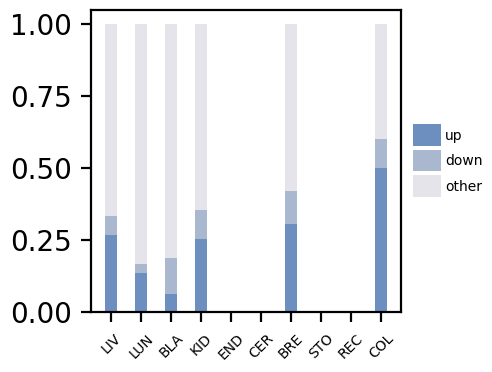

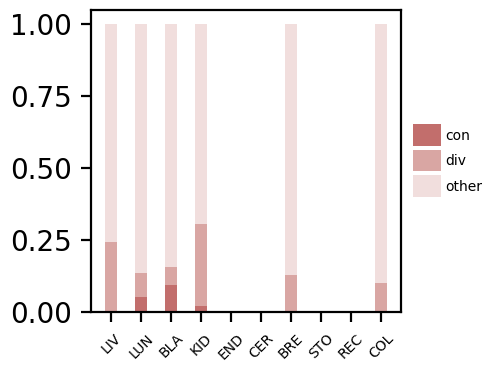

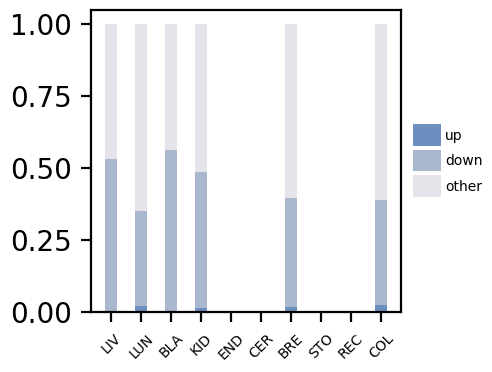

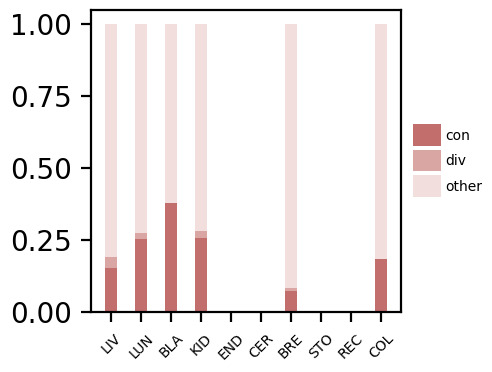

In [323]:
for i in ['up','down']:
    for j in ['up_down','con_div']:
        ir_sig_bar_plot(i,j)

In [225]:
test

,A1300690D15TN1,A1300690D15TT1,A1300741D09TN1,A1300741D09TT1,A1300745D15TN1,A1300745D15TT1,A1300750D15TN1,A1300750D15TT1,A1300752D15TN1,A1300752D15TT1,...,A2102918rccTN1,A2102918rccTT1,A2102919rccTN1,A2102919rccTT1,A2103518D15TN1,A2103518D15TT1,A511,A513,A561,A563
GENEID,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.15,20.0,298.0,47.0,45.00000,43.00000,712.0,145.0,203.00000,121.00000,92.0,...,276.0,123.0,231.0,52.0,125.0,171.0,225.00000,297.00000,116.0,166.0
ENSG00000000005.6,0.0,3.0,0.0,0.00000,1.00000,6.0,4.0,0.00000,0.00000,8.0,...,1.0,1.0,4.0,1.0,1.0,0.0,21.00000,27.00000,0.0,45.0
ENSG00000000419.14,47.0,98.0,31.0,30.00000,52.99999,80.0,61.0,116.99999,159.99999,158.0,...,57.0,71.0,63.0,56.0,78.0,36.0,258.00001,254.99999,385.0,227.0
ENSG00000000457.14,11.0,0.0,0.0,17.00000,0.00000,0.0,0.0,0.00000,11.00000,25.0,...,0.0,0.0,0.0,0.0,11.0,16.0,0.00000,0.00000,0.0,0.0
ENSG00000000460.17,2.0,0.0,0.0,8.00001,0.00000,0.0,0.0,0.00000,7.00000,8.0,...,0.0,0.0,0.0,0.0,8.0,14.0,0.00000,0.00000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000291297.1,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.00000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0
ENSG00000291298.1,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0,0.00000,0.00000,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.0,0.0
ENSG00000291299.1,0.0,0.0,2.0,0.00000,0.00000,0.0,1.0,0.00000,1.00000,0.0,...,1.0,0.0,0.0,0.0,4.0,0.0,0.00000,0.00000,0.0,0.0


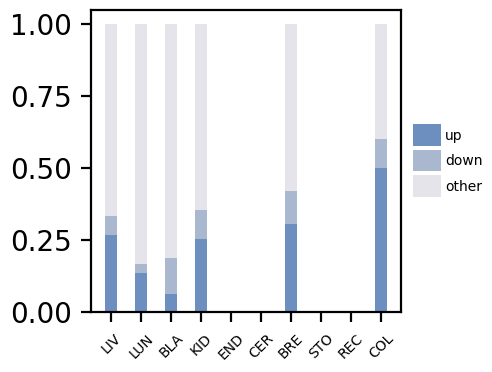

In [316]:
fig,ax = plt.subplots(figsize=(2,2),dpi=200)
label = [i for i in up_down_df.columns]
width = .4
n = 1
# colors_template = ['#de534d','#f9a664', '#fdea9f', '#edf9a9', '#a4d9a7', '#4e9fb2','#1f5877'][::-1]
colors_template = ['#6d8fbf','#a9b8cf','#e4e4ea']
# colors_template = sns.color_palette("Spectral")
# bar_data = bar_data.reindex(["SE", "A3", "A5", "AF","RI", "AL","MX"])
test = up_up_down_df/up_up_down_df.sum()
subategory = up_down_df.index
ax.bar(label, test.iloc[0,:].values, width, label=subategory[0],color=colors_template[0])
for l in range(2):
    ax.bar(label, test.iloc[n,:].values, width, bottom=test.iloc[:n,:].sum(), label=subategory[n],color=colors_template[n])
    n+=1
    ax.legend(fontsize=5,frameon=False,loc='center',ncol=1,bbox_to_anchor=(1.15, 0.5))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45,fontsize=5)
plt.savefig('/data1/DYY/plot/ir_sig_up_up_down.pdf',format='pdf',bbox_inches='tight')

In [347]:
test_con = con_div_df/con_div_df.sum()

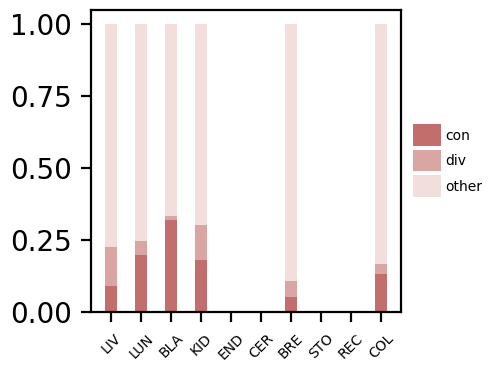

In [277]:
fig,ax = plt.subplots(figsize=(2,2),dpi=200)
label = [i for i in con_div_df.columns]
width = .4
n = 1
colors_template = ['#c26e6c','#d9a6a3', '#f1dedd']
test_con = con_div_df/con_div_df.sum()
# colors_template = sns.color_palette("Spectral")
# bar_data = bar_data.reindex(["SE", "A3", "A5", "AF","RI", "AL","MX"])
subategory = con_div_df.index
ax.bar(label, test_con.iloc[0,:].values, width, label=subategory[0],color=colors_template[0])
for l in range(2):
    ax.bar(label, test_con.iloc[n,:].values, width, bottom=test_con.iloc[:n,:].sum(), label=subategory[n],color=colors_template[n])
    n+=1
    ax.legend(fontsize=5,frameon=False,loc='center',ncol=1,bbox_to_anchor=(1.15, 0.5))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45,fontsize=5)
plt.savefig('/data1/DYY/plot/ir_sig_con_div.pdf',format='pdf',bbox_inches='tight')

In [40]:
import seaborn as sns

In [271]:
p_value_t = pd.DataFrame(index=test.index,columns=test.columns)

In [273]:
for k in test.columns:
    p = padj_dict[k].loc[padj_dict[k].index.isin(test.index)]
    p_value_t.loc[p.index,k] = p[k].tolist()

In [276]:
p_value_t.reset_index().merge(gene_name).set_index('gene_name').drop(['transcript','ensg','mstrg'],axis=1).to_csv('/data1/DYY/data/ir_sig_dotplot_data_figure4/p_value.csv',sep='\t')

In [216]:
test.reset_index().merge(gene_name).set_index('gene_name').drop(['transcript','ensg','mstrg'],axis=1).to_csv('/data1/DYY/data/ir_sig_dotplot_data_figure4/test_tumor.csv',sep='\t')
testn.reset_index().merge(gene_name).set_index('gene_name').drop(['transcript','ensg','mstrg'],axis=1).to_csv('/data1/DYY/data/ir_sig_dotplot_data_figure4/test_normal.csv',sep='\t')


In [337]:
testn.reset_index().rename(columns={'index':'transcript'}).merge(gene_name).set_index('gene_name').drop(['transcript','ensg','mstrg'],axis=1)

,A1804189PD1TN3,A1901742PD1TN3,A1900133PD1TN3,A1901243PD1TN3,A1900134PD1TN3,A1901740PD1TN3,A1901253PD1TN2,A1901242PD1TN3,A1804218PD1TN2,A1901739PD1TN2,A1804216PD1TN1,A1901744PD1TN1,A1803947PD1TN2,A1901248PD1TN2,A1900135PD1TN3,A1901247PD1TN2,A1803953PD1TN1,A1901244PD1TN3,A1901254PD1TN3
gene_name,,,,,,,,,,,,,,,,,,,
SFRP1,0.000000,4.913278,0.000000,47.354488,14.101926,50.217777,17.118694,20.524151,32.117031,40.309696,43.049423,16.131512,28.341335,24.244915,29.758055,21.260927,32.009014,21.255886,8.716384
PMP2,0.000000,1.063486,0.000000,6.030874,11.002371,2.145124,4.693738,4.458865,5.837497,2.246316,6.866812,6.884164,3.555094,1.431586,4.455062,8.764131,8.335213,3.944578,6.637029
CA3,0.000000,1.529729,0.000000,11.769114,102.189484,3.835447,2.446310,23.211065,7.694936,5.336294,3.643923,32.351479,7.058080,2.091698,0.000000,3.833242,6.129519,8.164430,4.092851
CNGB3,0.000000,0.000000,0.000000,0.656843,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.216845,0.000000
KCNA2,0.848316,1.634817,0.000000,1.297593,0.303703,3.083514,0.000000,2.213910,2.179600,1.225866,0.000000,2.597980,8.640424,0.000000,6.554784,1.540227,2.590199,0.609706,0.664770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DYNC1I1,0.000000,0.000000,1.153095,15.426677,14.112908,0.000000,21.903185,20.598734,0.000000,6.907845,1.657623,12.013966,3.630433,0.000000,2.450565,20.029272,12.676728,4.278624,19.627150
AGBL3,0.000000,0.000000,1.475856,0.497952,0.478671,0.627890,0.575406,0.846553,0.830490,0.000000,0.500665,0.746273,0.041132,0.000000,4.725056,0.640113,0.981698,0.609706,0.664770
VIPR2,2.300322,2.378517,2.503151,6.232966,7.662570,4.586210,3.049240,2.841046,3.113340,4.099600,5.290052,1.032109,8.389432,1.862776,6.587128,8.184781,15.487078,1.998546,4.604466
